## Imports

In [1]:
!pip install pymoo


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# IMPORTS
import numpy as np
import pandas as pd
import keras
from keras import layers
import random
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.termination.default import DefaultMultiObjectiveTermination
from pymoo.core.problem import Problem
from keras.utils import to_categorical

MAX_HARDWARE_VALUE = 6.0  # Maximum hardware value for devices
DOES_BATTERY_RUN_OUT = True  # Flag to indicate if battery can run out
UTILITY_DECREASE = 0.10   # Drop when device is selected and trains
UTILITY_INCREASE = 0.05   # Recovery when device is skipped in a round

## Classes

In [3]:
# CLASSES

class Device:
    def __init__(self, id, ram, storage, cpu, bandwidth, battery, charging):
        self.id = id
        self.ram = ram
        self.storage = storage
        self.cpu = cpu
        self.bandwidth = bandwidth
        self.battery = battery
        self.charging = charging
        self.model: keras.Sequential = Server.create_model()
        self.last_round_participated = 0
        self.data = None  # Placeholder for dataset partition
        self.test_data = None
        self.number_of_times_fitted = 0
        self.hardware_value_sum = 0.0
        
        self.utility_score: float = 1.0  # Initialize utility score to 1.0
    
    @property
    def is_off(self):
        # Battery is deprecated; utility_score is the hard participation gate
        return self.utility_score <= 0.0
    
    def fit(self, x_train, y_train, epochs=1, verbose=0):
        # if DOES_BATTERY_RUN_OUT:
        #     if self.battery > 0.2:
        #         self.battery -= 0.1
        #         self.model.fit(x_train, y_train, epochs=epochs, verbose=verbose)
        #     else:
        #         self.battery = 0
        #         print("device turned off!")
        # else:
            self.model.fit(x_train, y_train, epochs=epochs, verbose=verbose)

    def lose_battery(self):
        if self.hardware_value_sum > 0.3:
            self.hardware_value_sum -= 0.3
        else:
            self.hardware_value_sum = 0
            print("device turned off!")

class Server:
    def __init__(self, devices_list: list[Device]):
        self.model: keras.Sequential = Server.create_model()
        self.current_learning_iteration = 0
        self.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES = []
        self.x_test_global = []
        self.y_test_global = []
        self.devices = devices_list
               
        # The variables below are used to keep track of the remaining rounds and generations and to store the variances
        # They do not logically belong to the Server class
        self.remaining_generation = 0
        self.remaining_round = 0
        self.variances = []  # List to store variances as [round, gen, solution, variance]
        self.pareto_fronts = [] # List to store pareto fronts as [round, gen, solution]

    def evaluate(self, x_test=None, y_test=None, verbose = 0):
        if x_test is None and y_test is None:
            test_loss, test_acc = self.model.evaluate(self.x_test_global, self.y_test_global, verbose)
            return test_loss, test_acc
        test_loss, test_acc = self.model.evaluate(x_test, y_test, verbose=verbose)
        return test_loss, test_acc

    def get_weights(self):
        return self.model.get_weights()

    def give_global_model_weights_to_bitstring_devices(self, bitstring):
        for device in self.devices:
            if int(bitstring[int(device.id)]) == 1 and not device.is_off:
                device.model.set_weights(self.model.get_weights())

    def create_model() -> keras.Sequential:
        model = keras.Sequential([
            layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
                        loss='categorical_crossentropy', metrics=['accuracy'])
        return model

    def aggregate_weights(self, bitstring):
        """Computes the weighted average of model weights from all devices and updates the global model."""
        def sum_all_nested_lists(list_of_lists):
            def recursive_sum(lists):
                if isinstance(lists[0], list):
                    return [recursive_sum([lst[i] for lst in lists]) for i in range(len(lists[0]))]
                else:
                    return sum(lists)

            return recursive_sum(list_of_lists)

        def multiply_nested_list(lst, factor):
            result = []
            for item in lst:
                if isinstance(item, list):
                    # Recursively handle sublists
                    result.append(multiply_nested_list(item, factor))
                else:
                    # Multiply number
                    result.append(item * factor)
            return result

        selected_devices: list[Device] = []
        for device in self.devices:
            if int(bitstring[int(device.id)]) == 1 and device.is_off == False:
                selected_devices.append(device)

        num_devices = len(selected_devices)
        if num_devices == 0:
            print("No devices available for aggregation.")
            return
        
        data_lengths = []

        for device in selected_devices:
            data_lengths.append(len(device.data[0]))

        sum_data = 0
        for data_len in data_lengths:
            sum_data += data_len

        data_fractions = []
        for device in selected_devices:
            data_fractions.append(len(device.data[0])/float(sum_data))

        normalized_weights = data_fractions

        aggregated_weights_devices = []
        for d in range(len(selected_devices)):
            aggregated_weights_devices.append(multiply_nested_list(self.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(selected_devices[d].id)], normalized_weights[d]))

        aggregated_weights = sum_all_nested_lists(aggregated_weights_devices)

        return aggregated_weights


class NodeSelectionProblem(Problem):
    def __init__(self, devices: list[Device], server: Server, max_number_of_generations, max_number_of_rounds):
        super().__init__(
            n_var=len(devices),         # Number of variables (bitstring length)
            n_obj=3,                   # Number of objectives
            n_constr=0,                # No constraints
            xl=np.zeros(len(devices)),  # Lower bound (0)
            xu=np.ones(len(devices)),   # Upper bound (1)
            type_var=np.bool_          # Binary variables (bitstrings)
        )
        self.MAX_NUMBER_OF_GENERATIONS = max_number_of_generations
        self.MAX_NUMBER_OF_ROUNDS = max_number_of_rounds
        self.devices = devices
        self.server = server
        self.x_test_global = server.x_test_global
        self.y_test_global = server.y_test_global

        # Save the initial global model weights
        self.initial_global_weights = server.get_weights()

    def _evaluate(self, X, out, *args, **kwargs):
        MAX_NUMBER_OF_GENERATIONS = self.MAX_NUMBER_OF_GENERATIONS
        MAX_NUMBER_OF_ROUNDS = self.MAX_NUMBER_OF_ROUNDS
        """Evaluates objective values for each solution in the population."""
        num_solutions = len(X)
        F = np.zeros((num_solutions, 3))  # Initialize objective matrix

        for i, bitstring in enumerate(X):
            # print(f"evaluating: {bitstring}")
            # TODO: check bitstring type
            # Update device participation based on the bitstring
            selected_devices = [device for device, bit in zip(self.devices, bitstring) if int(bit) == 1]
            alive_selected = [d for d in selected_devices if not d.is_off]

            # Objective 1: Hardware Objectives (maximize)
            if len(selected_devices) == 0:
                F[i, 0] = 1.0  # Worst possible score
            else:
                # hardware_overhead = 0.0
                # for device in selected_devices:
                    # device_hardware_overhead = float(MAX_HARDWARE_VALUE - (device.hardware_value_sum * 5.0/6.0 + device.battery)) / MAX_HARDWARE_VALUE
                    # hardware_overhead += device_hardware_overhead

                # F[i, 0] = round(hardware_overhead/len(selected_devices), 2)  # Minimize (positive of hardware overhead)  # Added (/Selected Devices) to normalize between 0 and 1
                
                avg_utility = np.mean([device.utility_score for device in selected_devices])
                F[i, 0] = round(1.0 - avg_utility, 2)

            # Objective 2: Fairness (maximize)
            if len(alive_selected) == 0:
                F[i, 1] = 1.0
            else:
                fairness_score = 0
                for device in alive_selected:
                    _, accuracy = self.server.evaluate(device.test_data[0], device.test_data[1], verbose=0)
                    fairness_score += accuracy
                F[i, 1] = round(fairness_score / len(alive_selected), 2)

            # Objective 3: Global Model Accuracy (Performance) (maximize)
            if len(alive_selected) == 0:
                F[i, 2] = 1.0
            else:
                temp_global_model = Server.create_model()
                temp_global_model.set_weights(self.performance_objective_aggregation(alive_selected))
                _, global_accuracy = temp_global_model.evaluate(
                    self.server.x_test_global, self.server.y_test_global, verbose=0
                )
                F[i, 2] = round(1 - global_accuracy, 2)

        # self.server.remaining_generation -= 1    moved to ParetoLogger.notify()
        out["F"] = F  # Set the objective values

    def performance_objective_aggregation(self, selected_devices: list[Device]):
        # Build a temporary bitstring from the selected devices
        bitstring = [0] * len(self.server.devices)
        for device in selected_devices:
            bitstring[int(device.id)] = 1
        return self.server.aggregate_weights(bitstring)
    
    
        # def sum_all_nested_lists(list_of_lists):
        #     def recursive_sum(lists):
        #         if isinstance(lists[0], list):
        #             return [recursive_sum([lst[i] for lst in lists]) for i in range(len(lists[0]))]
        #         else:
        #             return sum(lists)

        #     return recursive_sum(list_of_lists)

        # def multiply_nested_list(lst, factor):
        #     result = []
        #     for item in lst:
        #         if isinstance(item, list):
        #             # Recursively handle sublists
        #             result.append(multiply_nested_list(item, factor))
        #         else:
        #             # Multiply number
        #             result.append(item * factor)
        #     return result

        # selected_devices = [device for device in selected_devices if device.is_off == False]
        
        # num_devices = len(selected_devices)
        # if num_devices == 0:
        #     print("No devices available for aggregation.")
        #     return

        # data_lengths = []

        # for device in selected_devices:
        #     data_lengths.append(len(device.data[0]))


        # sum_data = 0
        # for data_len in data_lengths:
        #     sum_data += data_len

        # data_fractions = []
        # for device in selected_devices:
        #     data_fractions.append(len(device.data[0])/float(sum_data))

        # normalized_weights = data_fractions

        # aggregated_weights_devices = []
        # for d in range(len(selected_devices)):
        #     aggregated_weights_devices.append(multiply_nested_list(self.server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(selected_devices[d].id)], normalized_weights[d]))

        # aggregated_weights = sum_all_nested_lists(aggregated_weights_devices)
        # return aggregated_weights




## Functions

In [4]:
# Functions

def fit_bitstring_devices(bitstring, server: Server, epochs=7):
    '''
    server: for using its "current_learning_iteration" variable
    '''

    server.current_learning_iteration += 1
    for device in server.devices:
        if int(bitstring[int(device.id)]) == 1 and device.is_off == False:
            # makes it so that the selection might choose a device that's been turned off
            # if the device is off, don't fit, use old weights saved on the server.
            # if the device is on, fit, update the weights saved on the server.
            device.fit(device.data[0], device.data[1], epochs=epochs, verbose=0)
            
            device.last_round_participated = server.current_learning_iteration
            server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(device.id)] = device.model.get_weights()
            device.number_of_times_fitted += 1
            device.utility_score = max(0.0, round(device.utility_score - UTILITY_DECREASE, 2))




def niid_labeldir_split(x_data, y_data, num_clients, beta, seed=None):
    num_classes = 10
    y_indices = np.array([np.argmax(label) for label in y_data])  # From one-hot to class index
    
    rng = np.random.default_rng(seed)  # Local random generator

    # Prepare client partitions
    client_indices = [[] for _ in range(num_clients)]

    for k in range(num_classes):
        idx_k = np.where(y_indices == k)[0]
        rng.shuffle(idx_k)

        # Dirichlet distribution for class k
        proportions = rng.dirichlet(np.repeat(beta, num_clients))

        # Scale proportions to match the number of available samples
        proportions = np.array([int(p * len(idx_k)) for p in proportions])
        # Fix total due to rounding
        while sum(proportions) < len(idx_k):
            proportions[np.argmin(proportions)] += 1
        while sum(proportions) > len(idx_k):
            proportions[np.argmax(proportions)] -= 1

        start = 0
        for i in range(num_clients):
            size = proportions[i]
            client_indices[i].extend(idx_k[start:start + size])
            start += size

    return client_indices


def random_hardware_value_for_devices(devices: list[Device]):
    random_values = [3.91, 0.62, 1.79, 4.96, 5.87, 2.14, 1.41, 5.18, 2.80, 3.00, 0.20, 1.02, 5.73, 0.69, 4.27,
                     5.37, 1.62, 0.93, 3.61, 2.90, 4.53, 2.13, 3.01, 0.07, 1.34, 3.90, 0.28, 1.89, 5.95, 2.76]
    
    for idx in range(len(devices)):
        devices[idx].hardware_value_sum = random_values[idx]
    
    print("Successfully gave each device a random value between 0 and 6 for its hardware objective!")


## Load Data

### Load Devices

In [5]:
# Load dataset from CSV
csv_file = 'devices.csv'
df = pd.read_csv(csv_file)
df.columns = df.columns.str.strip().str.lower()

# Convert CSV rows into device objects
devices = []

for _, row in df.iterrows():
    device = Device(
        row['id'], row['ram'], row['storage'], row['cpu'], row['bandwidth'], row['battery'],
        row.get('charging', 0)
    )
    device.utility_score = row['battery']
    devices.append(device)


# LIMIT TO 30 DEVICES
devices = devices[:30]

random_hardware_value_for_devices(devices)

d:\Github Repos\FL\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Successfully gave each device a random value between 0 and 6 for its hardware objective!


### Object Initializations

In [6]:
for device in devices:
    print(device.id)
    print(device.hardware_value_sum)
    print(device.battery)
    print(device.battery+device.ram+device.storage+device.cpu+device.bandwidth+device.charging)

0.0
3.91
0.1031238688359326
2.4928382735072256
1.0
0.62
0.9025529066795668
3.2849102894927706
2.0
1.79
0.5052523724478571
2.479004755181064
3.0
4.96
0.8264574661077416
3.6053494049560646
4.0
5.87
0.3200496010306117
2.8765445580063145
5.0
2.14
0.8955232284962005
2.546825521004018
6.0
1.41
0.3892016787341631
2.7668162624681143
7.0
5.18
0.0108376514802983
2.758204625210855
8.0
2.8
0.9053819764192635
3.7725268366840417
9.0
3.0
0.0912866767861335
2.5863101880601036
10.0
0.2
0.3193136375904148
1.8875506791440282
11.0
1.02
0.9500619670508048
3.061396413656667
12.0
5.73
0.950607146937556
4.546114213392503
13.0
0.69
0.5734378881232861
2.9600773810663465
14.0
4.27
0.6318372121697993
3.158886471189339
15.0
5.37
0.4484455219783197
3.6377250762468045
16.0
1.62
0.2932107716980645
3.3512510378870353
17.0
0.93
0.3286645453699159
2.1966655395063452
18.0
3.61
0.6725184560770384
3.990035019042393
19.0
2.9
0.75237452943768
2.8894084511328995
20.0
4.53
0.7915790437258485
3.555098389929464
21.0
2.13
0.78961

In [7]:
# Global Model
server = Server(devices_list=devices)
server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES = [None for _ in range(len(devices))]

### Split Data Among Devices

In [8]:
SEED = 1
np.random.seed(SEED)
np.random.randint(1, 11)

6

In [9]:


# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Convert labels to categorical (one-hot encoded)
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Normalize data and reshape for CNN
x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)  # Add channel dimension

x_test = x_test.astype("float32") / 255.0
x_test = np.expand_dims(x_test, -1)  # Add channel dimension


# Lower the amount of data for devices
x_train = x_train[:int(len(x_train)/4)] # was 8
y_train = y_train[:int(len(y_train)/4)]


# Correct test split
split_index = int(0.8 * len(x_test))
x_test_devices, y_test_devices = x_test[:split_index], y_test[:split_index]
server.x_test_global, server.y_test_global = x_test[split_index:], y_test[split_index:]

# Training data (for devices)
x_train_devices, y_train_devices = x_train, y_train

# Split training data among devices
alpha = 0.1  # lower = more skewed
num_devices = len(devices)
split_indices = niid_labeldir_split(x_train_devices, y_train_devices, num_devices, alpha, seed=SEED)

for i, device in enumerate(devices):
    idxs = split_indices[i]

    from sklearn.model_selection import train_test_split

    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(x_train_devices[idxs], y_train_devices[idxs], test_size=0.3, random_state=42)

    device.data = [X_train, y_train]
    device.test_data = [X_test, y_test]

    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)
    print("y_train shape:", y_train.shape)
    print("y_test shape:", y_test.shape)


#TODO:
# how does each objective get better through populations? maybe put em on a scale

X_train shape: (246, 28, 28, 1)
X_test shape: (106, 28, 28, 1)
y_train shape: (246, 10)
y_test shape: (106, 10)
X_train shape: (149, 28, 28, 1)
X_test shape: (65, 28, 28, 1)
y_train shape: (149, 10)
y_test shape: (65, 10)
X_train shape: (424, 28, 28, 1)
X_test shape: (183, 28, 28, 1)
y_train shape: (424, 10)
y_test shape: (183, 10)
X_train shape: (234, 28, 28, 1)
X_test shape: (101, 28, 28, 1)
y_train shape: (234, 10)
y_test shape: (101, 10)
X_train shape: (246, 28, 28, 1)
X_test shape: (106, 28, 28, 1)
y_train shape: (246, 10)
y_test shape: (106, 10)
X_train shape: (144, 28, 28, 1)
X_test shape: (63, 28, 28, 1)
y_train shape: (144, 10)
y_test shape: (63, 10)
X_train shape: (79, 28, 28, 1)
X_test shape: (35, 28, 28, 1)
y_train shape: (79, 10)
y_test shape: (35, 10)
X_train shape: (563, 28, 28, 1)
X_test shape: (242, 28, 28, 1)
y_train shape: (563, 10)
y_test shape: (242, 10)
X_train shape: (419, 28, 28, 1)
X_test shape: (180, 28, 28, 1)
y_train shape: (419, 10)
y_test shape: (180, 10)


### NonIID-ness visualization

In [10]:
print(devices[0].data[1])
onehot = devices[0].data[1]          # Your one-hot array
int_labels = np.argmax(onehot, axis=1)  # Convert
print(int_labels)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]]
[3 3 3 3 6 3 6 3 5 9 3 5 5 3 3 3 3 6 3 3 3 3 2 5 3 3 3 6 3 3 3 3 3 3 9 3 3
 3 3 3 5 3 7 3 3 3 3 3 3 6 5 3 3 3 3 6 3 6 6 5 3 5 3 6 3 3 3 5 6 3 3 6 3 6
 9 5 6 3 3 6 3 4 2 3 3 3 3 3 6 3 6 3 3 6 3 3 6 3 5 6 3 3 9 3 6 3 5 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 6 3 3 3 3 3 6 3 3 3 9 3 8 2 0 6 6 6 3 3 3 6 3 3 3 3
 3 3 3 3 3 3 3 6 3 6 3 5 3 6 3 3 3 3 2 3 3 3 3 6 6 3 6 6 3 3 3 6 5 9 6 5 3
 3 3 3 3 5 3 3 1 3 3 3 3 5 3 3 5 5 3 3 6 3 9 3 6 9 5 3 3 3 3 9 3 3 3 3 3 5
 3 6 3 6 3 6 5 6 3 3 3 3 3 6 3 3 9 3 3 3 3 5 9 3]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ============================================================
# STEP 1: Build distribution from your devices
# ============================================================

def build_distribution(devices, data_attr='data', label_index=1):
    """
    Build label distribution from devices with one-hot encoded labels.
    
    devices: list of your device objects
    data_attr: attribute name that holds the tuple/list (default: 'data')
    label_index: index in that tuple for the labels (default: 1 for .data[1])
    """
    num_devices = len(devices)
    num_classes = 10
    raw_counts = np.zeros((num_devices, num_classes), dtype=int)
    
    for i, device in enumerate(devices):
        # Get the one-hot labels: shape (N, 10)
        onehot_labels = getattr(device, data_attr)[label_index]
        
        # Convert one-hot → integer labels: shape (N,)
        # argmax finds which column has the 1
        int_labels = np.argmax(onehot_labels, axis=1)
        
        # Count occurrences of each digit 0-9
        for label in range(num_classes):
            raw_counts[i, label] = np.sum(int_labels == label)
    
    # Convert to proportions (each row sums to 1)
    row_sums = raw_counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    distribution = raw_counts / row_sums
    
    return distribution, raw_counts  # Return both for debugging

# ============================================================
# STEP 2: Metrics (all take 'devices' directly, or 'dist')
# ============================================================

def calculate_emd_per_device(devices=None, distribution=None):
    """Pass EITHER devices OR distribution"""
    from scipy.stats import wasserstein_distance
    
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    num_classes = dist.shape[1]
    global_dist = np.ones(num_classes) / num_classes
    
    emd_scores = []
    for i in range(len(dist)):
        # Scale up to integer samples for wasserstein_distance
        device_samples = np.repeat(np.arange(num_classes), (dist[i] * 10000).astype(int))
        global_samples = np.repeat(np.arange(num_classes), (global_dist * 10000).astype(int))
        emd = wasserstein_distance(device_samples, global_samples)
        emd_scores.append(emd)
    
    return np.array(emd_scores)

# ============================================================
# STEP 3: Visualization (all take 'devices' directly)
# ============================================================

def plot_heatmap_fixed(devices):
    dist, counts = build_distribution(devices)
    
    fig, ax = plt.subplots(figsize=(14, max(6, len(devices) * 0.35)))
    
    im = ax.imshow(dist, aspect='auto', cmap='YlOrRd', vmin=0, vmax=dist.max())
    
    ax.set_xticks(range(10))
    ax.set_xticklabels([f'{i}' for i in range(10)])
    ax.set_yticks(range(len(devices)))
    ax.set_yticklabels([f'Device {i}' for i in range(len(devices))])
    
    ax.set_xlabel('MNIST Digit')
    ax.set_ylabel('Device')
    ax.set_title('Label Distribution Heatmap')
    
    # Add text annotations where proportion > 0.05
    for i in range(len(devices)):
        for j in range(10):
            if dist[i, j] >= 0.05:
                color = "white" if dist[i, j] > 0.5 else "black"
                ax.text(j, i, f'{dist[i, j]:.2f}',
                       ha="center", va="center", color=color, fontsize=7)
    
    plt.colorbar(im, ax=ax, label='Proportion')
    plt.tight_layout()
    # plt.show()   # Shown in another cell below as well
    
    # Print summary
    print("\n--- Distribution Summary ---")
    for i in range(len(devices)):
        dominant = np.argmax(dist[i])
        print(f"Device {i:2d}: {counts[i].sum():4d} samples | "
              f"dominant digit: {dominant} ({dist[i, dominant]:.1%})")
    
    return dist

# ============================================================
# USAGE: Just pass your devices list
# ============================================================

# dist = plot_heatmap_fixed(devices)
# emd_scores = calculate_emd_per_device(devices)

NON-IID ANALYSIS SUMMARY
Number of devices: 30
Total samples: 10485

--- Heterogeneity Metrics ---
Mean EMD: 2.1739 ± 0.8001
Mean KL Divergence: 1.4159 ± 0.3748
Max EMD (worst device): 4.1379
Estimated Dirichlet α: 2.2451 (lower = more heterogeneous)

Most skewed device: Device 15
  Top 3 digits: [0 8 6]
  Concentration: 94.0% in one class

Non-IID Severity: Severe


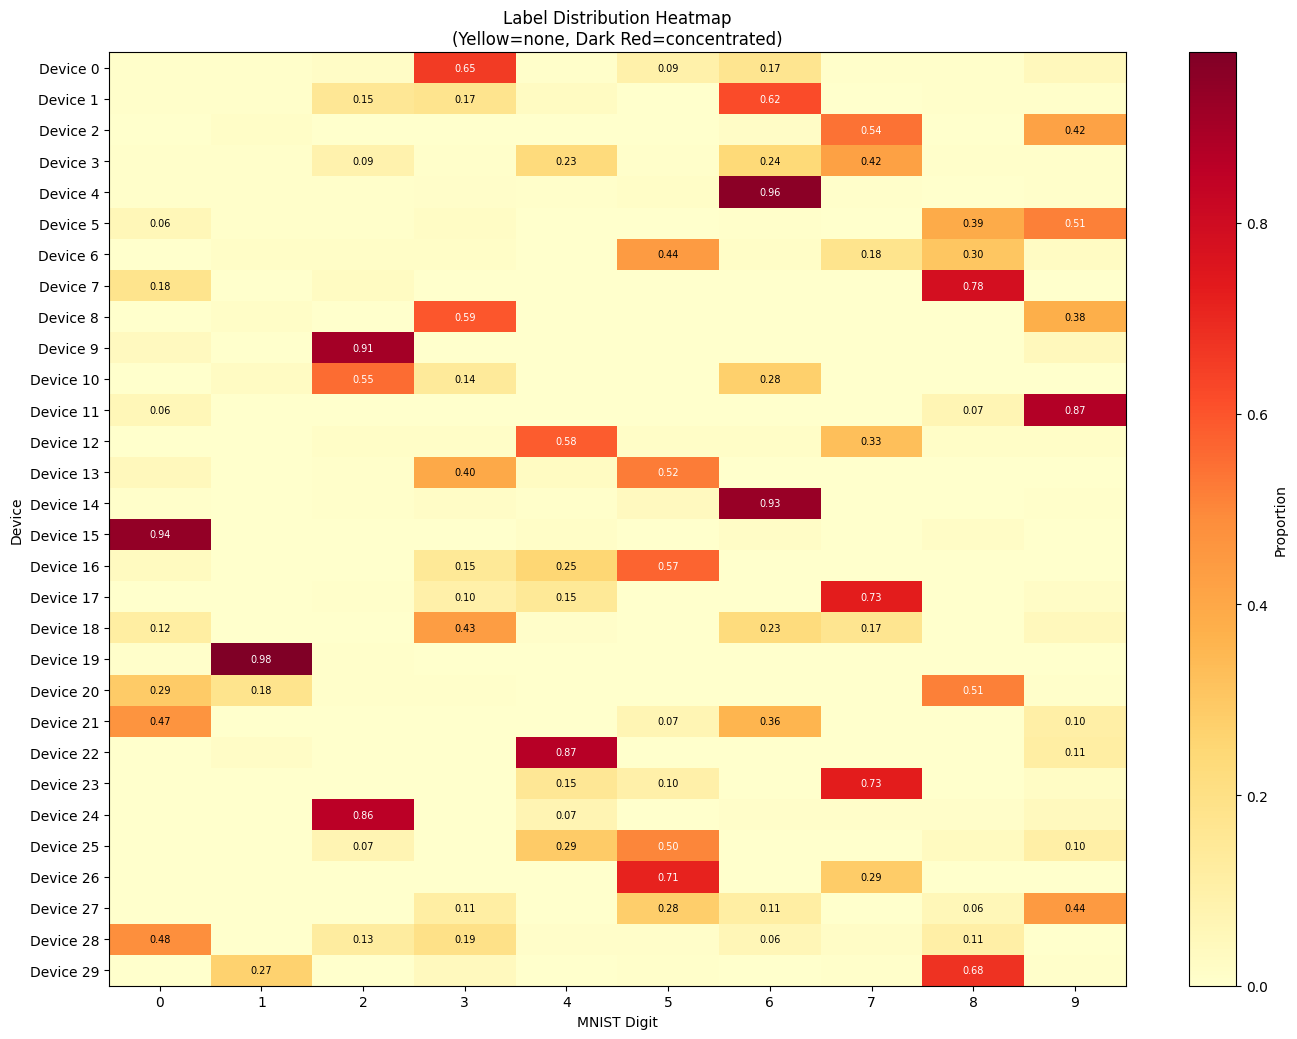

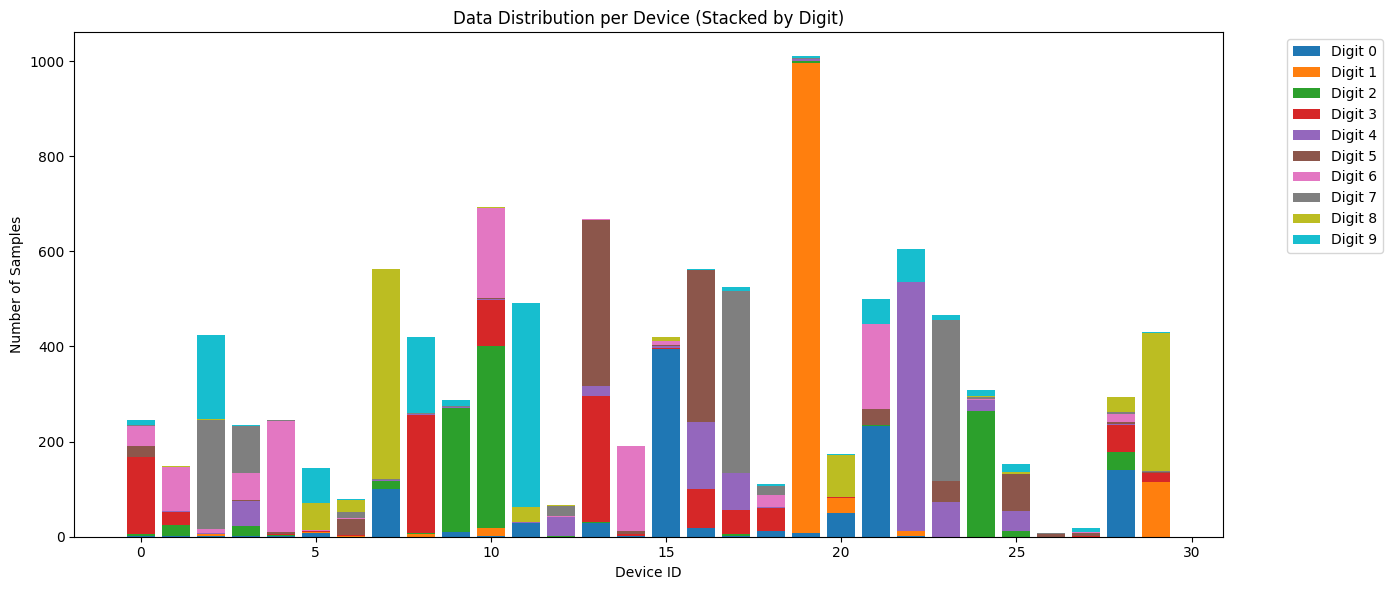

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import wasserstein_distance
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ============================================================
# CORE: Build distribution from your devices
# ============================================================

def build_distribution(devices, data_attr='data', label_index=1):
    """
    Build label distribution from devices with one-hot encoded labels.
    Returns: (distribution, raw_counts) tuple
    """
    num_devices = len(devices)
    num_classes = 10
    raw_counts = np.zeros((num_devices, num_classes), dtype=int)
    
    for i, device in enumerate(devices):
        onehot_labels = getattr(device, data_attr)[label_index]
        int_labels = np.argmax(onehot_labels, axis=1)
        for label in range(num_classes):
            raw_counts[i, label] = np.sum(int_labels == label)
    
    row_sums = raw_counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    distribution = raw_counts / row_sums
    
    return distribution, raw_counts


# ============================================================
# METRICS
# ============================================================

def calculate_euclidean_per_device(devices=None, distribution=None):
    """Euclidean distance from uniform distribution per device"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    num_classes = dist.shape[1]
    global_dist = np.ones(num_classes) / num_classes
    
    # Vectorized: sqrt(sum((P - Q)^2)) for all devices at once
    return np.sqrt(np.sum((dist - global_dist) ** 2, axis=1))


def calculate_emd_per_device(devices=None, distribution=None):
    """Earth Mover's Distance from uniform distribution per device"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    num_classes = dist.shape[1]
    global_dist = np.ones(num_classes) / num_classes
    
    emd_scores = []
    for i in range(len(dist)):
        device_samples = np.repeat(np.arange(num_classes), (dist[i] * 10000).astype(int))
        global_samples = np.repeat(np.arange(num_classes), (global_dist * 10000).astype(int))
        emd = wasserstein_distance(device_samples, global_samples)
        emd_scores.append(emd)
    
    return np.array(emd_scores)


def calculate_kl_divergence(devices=None, distribution=None, epsilon=1e-10):
    """KL(P_device || P_global) for each device"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    num_classes = dist.shape[1]
    global_dist = np.ones(num_classes) / num_classes
    
    kl_scores = []
    for i in range(len(dist)):
        p = dist[i] + epsilon
        q = global_dist
        kl = np.sum(p * np.log(p / q))
        kl_scores.append(kl)
    
    return np.array(kl_scores)


def estimate_dirichlet_alpha(devices=None, distribution=None):
    """Rough estimate of Dirichlet concentration parameter. Lower = more heterogeneous."""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    variances = np.var(dist, axis=0)
    mean_var = np.mean(variances)
    estimated_alpha = 0.1 / (mean_var + 0.001)
    return estimated_alpha


# ============================================================
# VISUALIZATIONS
# ============================================================

def plot_heatmap(devices=None, distribution=None):
    """Label distribution heatmap across devices"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    fig, ax = plt.subplots(figsize=(14, max(6, len(dist) * 0.35)))
    
    im = ax.imshow(dist, aspect='auto', cmap='YlOrRd', vmin=0, vmax=dist.max())
    
    ax.set_xticks(range(10))
    ax.set_xticklabels([f'{i}' for i in range(10)])
    ax.set_yticks(range(len(dist)))
    ax.set_yticklabels([f'Device {i}' for i in range(len(dist))])
    
    ax.set_xlabel('MNIST Digit')
    ax.set_ylabel('Device')
    ax.set_title('Label Distribution Heatmap\n(Yellow=none, Dark Red=concentrated)')
    
    for i in range(len(dist)):
        for j in range(10):
            if dist[i, j] >= 0.05:
                color = "white" if dist[i, j] > 0.5 else "black"
                ax.text(j, i, f'{dist[i, j]:.2f}',
                       ha="center", va="center", color=color, fontsize=7)
    
    plt.colorbar(im, ax=ax, label='Proportion')
    plt.tight_layout()
    plt.show()
    
    return dist


def plot_stacked_bars(devices):
    """Stacked bar chart showing absolute data volume per device with class breakdown"""
    dist, counts = build_distribution(devices)
    num_devices = len(devices)
    num_classes = 10
    
    fig, ax = plt.subplots(figsize=(14, 6))
    bottom = np.zeros(num_devices)
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
    
    for digit in range(num_classes):
        ax.bar(range(num_devices), counts[:, digit], 
               bottom=bottom, label=f'Digit {digit}', color=colors[digit])
        bottom += counts[:, digit]
    
    ax.set_xlabel('Device ID')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Data Distribution per Device (Stacked by Digit)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_divergence_summary(devices=None, distribution=None):
    """Box plots of EMD and KL divergence across devices"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    emd = calculate_emd_per_device(distribution=dist)
    kl = calculate_kl_divergence(distribution=dist)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].boxplot(emd, vert=True)
    axes[0].set_title(f'EMD from Uniform Distribution\n(Mean: {emd.mean():.3f})')
    axes[0].set_ylabel('Wasserstein Distance')
    
    axes[1].boxplot(kl, vert=True)
    axes[1].set_title(f'KL Divergence from Uniform\n(Mean: {kl.mean():.3f})')
    axes[1].set_ylabel('KL Divergence')
    
    plt.suptitle('Non-IID Severity Summary', fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_device_similarity(devices=None, distribution=None):
    """PCA plot clustering devices by label distribution similarity"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    pca = PCA(n_components=2)
    coords = pca.fit_transform(dist)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    scatter = ax.scatter(coords[:, 0], coords[:, 1], 
                        c=range(len(dist)), 
                        cmap='tab20', s=200, edgecolors='black')
    
    for i, (x, y) in enumerate(coords):
        ax.annotate(f'D{i}', (x, y), fontsize=10, ha='center', va='center')
    
    ax.set_title('Device Similarity by Label Distribution (PCA)\n'
                 'Closer devices = more similar data distributions')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.colorbar(scatter, label='Device ID')
    plt.tight_layout()
    plt.show()


# ============================================================
# COMPLETE ANALYSIS (runs everything)
# ============================================================

def full_noniid_analysis(devices):
    """Run complete non-IID analysis with all metrics and plots"""
    dist, counts = build_distribution(devices)
    
    # Metrics
    emd = calculate_emd_per_device(distribution=dist)
    kl = calculate_kl_divergence(distribution=dist)
    alpha = estimate_dirichlet_alpha(distribution=dist)
    
    # Summary
    print("=" * 55)
    print("NON-IID ANALYSIS SUMMARY")
    print("=" * 55)
    print(f"Number of devices: {len(devices)}")
    print(f"Total samples: {counts.sum()}")
    print(f"\n--- Heterogeneity Metrics ---")
    # TODO: ADD EUCLIDEAN DISTANCE HERE
    print(f"Mean EMD: {emd.mean():.4f} ± {emd.std():.4f}")
    print(f"Mean KL Divergence: {kl.mean():.4f} ± {kl.std():.4f}")
    print(f"Max EMD (worst device): {emd.max():.4f}")
    print(f"Estimated Dirichlet α: {alpha:.4f} (lower = more heterogeneous)")
    
    # Most skewed device
    worst_idx = np.argmax(emd)
    print(f"\nMost skewed device: Device {worst_idx}")
    top3 = np.argsort(dist[worst_idx])[-3:][::-1]
    print(f"  Top 3 digits: {top3}")
    print(f"  Concentration: {dist[worst_idx].max():.1%} in one class")
    
    # Severity classification
    mean_emd = emd.mean()
    if mean_emd < 0.5:
        severity = "Mild"
    elif mean_emd < 1.5:
        severity = "Moderate"
    else:
        severity = "Severe"
    print(f"\nNon-IID Severity: {severity}")
    print("=" * 55)
    
    # Generate all plots
    plot_heatmap(distribution=dist)
    plot_stacked_bars(devices)
    # plot_divergence_summary(distribution=dist)
    # plot_device_similarity(distribution=dist)
    
    return {
        'distribution': dist,
        'raw_counts': counts,
        'emd': emd,
        'kl': kl,
        'dirichlet_alpha': alpha,
        'severity': severity
    }


# ============================================================
# USAGE
# ============================================================

# Run everything:
results = full_noniid_analysis(devices)

# Or run individual functions:
# dist, counts = build_distribution(devices)
# plot_heatmap(distribution=dist)
# emd = calculate_emd_per_device(distribution=dist)

In [13]:
# test
a, b =devices[15].test_data
print(len(a))

181


### Load Other Data

## First Iteration

In [14]:
# First Iteration
bitstring = [1 for _ in range(len(devices))]
print(bitstring)



# Save weights to a file
# The file name should end in .weights.h5
# The weights can be loaded into a model using model.load_weights('model.weights.h5')
server.model.save_weights('my_model.weights.h5')

# global model sends its weights to all devices
server.give_global_model_weights_to_bitstring_devices(bitstring)



test_loss, test_acc = server.evaluate(verbose=0)
print(f"Global Model Accuracy: {test_acc:.2f}")
print("------------------------------------------------------------")
fit_bitstring_devices(bitstring, server)
server.model.set_weights(server.aggregate_weights(bitstring))
print("------------------------------------------------------------")
test_loss, test_acc = server.evaluate(verbose=0)
print(f"Global Model Accuracy: {test_acc:.2f}")

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1080 - loss: 2.3013
Global Model Accuracy: 0.11
------------------------------------------------------------
------------------------------------------------------------
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4736 - loss: 1.9512
Global Model Accuracy: 0.46


## NSGA2 Loop

In [15]:
# Parameters
POPULATION_SIZE = 50 # should be 100
NUM_GENERATIONS = 10 # should be 10
NUM_ROUNDS = 5 # should be 4

server.remaining_generation = NUM_GENERATIONS
server.remaining_round = NUM_ROUNDS

In [16]:
# Object Initializations

problem = NodeSelectionProblem(
    devices=devices,
    server=server,
    max_number_of_generations=NUM_GENERATIONS,
    max_number_of_rounds=NUM_ROUNDS
)


# Step 2: Configure NSGA-II Algorithm
algorithm = NSGA2(
    pop_size=POPULATION_SIZE,
    sampling=BinaryRandomSampling(),      # Random bitstrings
    crossover=TwoPointCrossover(),        # Two-point crossover
    mutation=BitflipMutation(),           # Bit flip mutation
    eliminate_duplicates=True             # Avoid duplicate solutions
)


In [17]:
# DEBUG:
print(server.x_test_global.shape)
print(server.y_test_global.shape)

print(x_train.shape)
print(y_train.shape)

(2000, 28, 28, 1)
(2000, 10)
(15000, 28, 28, 1)
(431, 10)


In [18]:
from pymoo.core.callback import Callback
import numpy as np

class ParetoLogger(Callback):
    def __init__(self, server: Server, devices: list[Device], max_rounds, max_generations):
        super().__init__()
        self.data["pareto_fronts"] = []     # Objective values F
        self.data["pareto_solutions"] = []  # Decision variables X
        
        
        
        self.server = server
        self.devices = devices
        self.max_rounds = max_rounds
        self.max_generations = max_generations
        self.variances = []  # Store variances as [round, gen, bitstring, variance]

    def notify(self, algorithm):
        self.server.remaining_generation -= 1
        opt = algorithm.opt
        gen = algorithm.n_gen
        if opt is not None:
            F = opt.get("F")
            X = opt.get("X")
            print(f"Generation {gen}: {len(X)} solutions in opt")  # ← Check this!
            self.data["pareto_fronts"].append(F.copy())
            self.data["pareto_solutions"].append(X.copy())
        
        
        # Get current round and generation
        round_idx = self.max_rounds - self.server.remaining_round
        # gen_idx = self.max_generations - self.server.remaining_generation + 1  # Adjust for current gen
        gen_idx = algorithm.n_gen # fixed

        # Get the non-dominated solutions (Pareto front) from the current population
        pop = algorithm.opt  # Non-dominated solutions (Pareto front)

        for ind in pop:
            bitstring = ind.X  # Bitstring for this individual
            bitstring_str = "".join(map(str, bitstring)).replace("True", "1").replace("False", "0")

            # Select devices based on the bitstring
            selected_devices = [device for device, bit in zip(self.devices, bitstring) if int(bit) == 1]

            # Calculate fairness (variance of global model accuracy on selected devices' test data)
            accuracies = []
            for device in selected_devices:
                _, accuracy = self.server.evaluate(device.test_data[0], device.test_data[1], verbose=0)
                accuracies.append(round(accuracy, 2))

            # Compute variance (handle edge case of no selected devices)
            if not accuracies:
                variance = 0.0  # Default value if no devices are selected
                print(f"No devices selected for bitstring {bitstring_str}, setting variance to 0")
            else:
                variance = round(1.0 / float(np.var(accuracies)) if np.var(accuracies) != 0 else float('inf'), 2)

            # Store the result
            # self.variances.append([round_idx, gen_idx-2, bitstring_str, variance])
            self.variances.append([round_idx, gen_idx, bitstring_str, variance])
            # print(f"Round {round_idx}, Gen {gen_idx-2}, Bitstring {bitstring_str}, Variance {variance}")
            print(f"Round {round_idx}, Gen {gen_idx}, Bitstring {bitstring_str}, Variance {variance}") # fixed with gen_idx = algorithm.n_gen

        # Optionally, update server.variances if you want to keep using it
        self.server.variances.extend(self.variances[-len(pop):])

In [19]:
all_runs_fronts = []  # Stores results across runs
all_runs_solutions = []

VARIANCES = []

needed_values_for_comparison = ""

for i in range(NUM_ROUNDS):
    server.remaining_round = NUM_ROUNDS - i
    server.remaining_generation = NUM_GENERATIONS
    # Step 3: Run Optimization
    print("GLOBAL MODEL BEFORE OPTIMIZATION")
    print(server.evaluate())

    callback = ParetoLogger(server=server, devices=server.devices, max_rounds=NUM_ROUNDS, max_generations=NUM_GENERATIONS)
    res = minimize(
        problem=problem,
        algorithm=algorithm,
        termination=DefaultMultiObjectiveTermination(n_max_gen=NUM_GENERATIONS),
        # seed=42,
        verbose=True,
        callback=callback
    )
    print("GLOBAL MODEL AFTER OPTIMIZATION")
    print(server.evaluate())


    # Step 4: Extract the Best Pareto Front
    pareto_front = res.F   # Objective values of solutions in Pareto front
    pareto_solutions = res.X  # Corresponding bitstrings

    # Print the Best Pareto Front Solutions
    # print("Best Pareto Front (Bitstrings):")
    # for bitstring in pareto_solutions:
        # print("".join(map(str, bitstring)).replace('True','1').replace('False','0'))




    # bitstring = pareto_solutions[0] # for now!
    # bitstring = str(bitstring).replace('False','0').replace('True','1')
    # for char in bitstring:
    #     if char != '0' and char != '1':
    #         bitstring = bitstring.replace(char,'')
            
    bitstring = pareto_solutions[0].astype(int).tolist()

    # print(len(bitstring))
    # print(bitstring)
    temp_bitstring = []
    for bit in bitstring:
        temp_bitstring.append(bit)
    bitstring = temp_bitstring

    
    ###############################
    bitstring = [int(bit) for bit in bitstring]
    print(bitstring)
    print(bitstring[0])
    print(type(bitstring[0]))
    # global model sends its weights to all devices
    server.give_global_model_weights_to_bitstring_devices(bitstring)

    test_loss, test_acc = server.evaluate(verbose=0)
    print(f"Global Model Accuracy: {test_acc:.2f}")
    print("------------------------------------------------------------")
    fit_bitstring_devices(bitstring, server)
    server.model.set_weights(server.aggregate_weights(bitstring))
    
    for device in server.devices:
            if int(bitstring[int(device.id)]) == 0:
                device.utility_score = min(1.0, round(device.utility_score + UTILITY_INCREASE, 2))
    print("------------------------------------------------------------")
    test_loss, test_acc = server.evaluate(verbose=0)
    print(f"Global Model Accuracy: {test_acc:.2f}")
    

    # Save the pareto fronts from this run
    all_runs_fronts.append(callback.data["pareto_fronts"])
    all_runs_solutions.append(callback.data["pareto_solutions"])

    # Save the variances from this run
    VARIANCES.extend(callback.variances)
    
    
    # ---
    accuracies = []

    for device in server.devices:
        x_test = device.test_data[0]
        y_test = device.test_data[1]
        
        loss, accuracy = server.evaluate(x_test, y_test)
        
        accuracies.append(round(accuracy, 2))
        print(f"Device {device.id} Accuracy: {round(accuracy, 2)}")

    VARIANCE = np.var(accuracies)
    VARIANCE_SCORE = 1.0/VARIANCE
    MEAN = np.mean(accuracies)
    STANDARD_DEVIATION = np.std(accuracies)
    FAIRNESS = 1.0/STANDARD_DEVIATION
    
    needed_values_for_comparison += f"Round: {i+1}\nServer Test Accuracy: {test_acc}\nVariance: {VARIANCE}\nVariance Score: {VARIANCE_SCORE}\nMean: {MEAN}\nStandard Deviation: {STANDARD_DEVIATION}\nFairness: {FAIRNESS}\n---\n"

GLOBAL MODEL BEFORE OPTIMIZATION
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4736 - loss: 1.9512
(1.970167636871338, 0.46399998664855957)


d:\Github Repos\FL\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |      8 |             - |             -
Generation 1: 8 solutions in opt
Round 0, Gen 1, Bitstring 010110111100011001111110000111, Variance 12.0
Round 0, Gen 1, Bitstring 000001000100000100001011011011, Variance 14.21
Round 0, Gen 1, Bitstring 000101101000101001011110101110, Variance 10.49
Round 0, Gen 1, Bitstring 100101100111101011010111011010, Variance 10.91
Round 0, Gen 1, Bitstring 011101111010111010110010011011, Variance 13.94
Round 0, Gen 1, Bitstring 000001100100011001100001111111, Variance 14.19
Round 0, Gen 1, Bitstring 010001000001100110011111011000, Variance 9.52
Round 0, Gen 1, Bitstring 001010000101110010101101001010, Variance 10.38
     2 |      100 |     10 |  0.4000000000 |         nadir
Generation 2: 10 solutions in opt
Round 0, Gen 2, Bitstring 000001000100000100001011011011, Variance 14.21
Round 0, Gen 2, Bitstring 000101101000101001011110101110, Variance 10.49
Round 0, Gen 2, Bitstring 10

In [20]:
for device in devices:
    print(device.battery)

0.1031238688359326
0.9025529066795668
0.5052523724478571
0.8264574661077416
0.3200496010306117
0.8955232284962005
0.3892016787341631
0.0108376514802983
0.9053819764192635
0.0912866767861335
0.3193136375904148
0.9500619670508048
0.950607146937556
0.5734378881232861
0.6318372121697993
0.4484455219783197
0.2932107716980645
0.3286645453699159
0.6725184560770384
0.75237452943768
0.7915790437258485
0.7896181427945539
0.0912061030486903
0.4944203047025814
0.0575587600166442
0.5495288823237355
0.441530501373377
0.8877041827582998
0.3509150125520787
0.1170670164276058


In [21]:
print(len(all_runs_fronts))
print(len(all_runs_solutions))

print(len(all_runs_fronts[0][0]))
print(all_runs_fronts[0][0])

5
5
8
[[0.57 0.56 0.54]
 [0.67 0.35 0.85]
 [0.49 0.46 0.56]
 [0.59 0.38 0.49]
 [0.56 0.42 0.66]
 [0.63 0.36 0.68]
 [0.46 0.44 0.73]
 [0.54 0.45 0.72]]


In [22]:
print(len(all_runs_solutions[0]))
print(str(all_runs_solutions[0][0][0]).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n",""))

10
[0,1,0,1,1,0,1,1,1,1,0,0,0,1,1,0,0,1,1,1,1,1,1,0,0,0,0,1,1,1]


In [23]:
print(server.variances[0])

[0, 1, '010110111100011001111110000111', 12.0]


In [24]:
print([str(solution).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n","") for solution in all_runs_solutions[1][1]])
print(([i[2] for i in server.variances if i[0] == 1 and i[1] == 1]))

x = [str(solution).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n","") for solution in all_runs_solutions[1][1]]
y = ([i[2] for i in server.variances if i[0] == 1 and i[1] == 1])

for item in x:
    if item in y:
        print("yea")
    else:
        print(item)
        print("nope")

['[1,1,1,0,0,0,1,0,0,0,1,0,1,1,1,1,0,0,0,1,1,1,1,1,1,0,1,1,0,0]', '[1,0,1,1,0,1,0,1,0,1,1,0,0,0,1,0,0,1,0,1,1,1,0,1,0,0,0,0,0,1]', '[0,1,0,0,0,0,0,0,1,0,1,1,1,0,0,0,1,0,0,1,1,0,0,0,1,1,1,1,1,0]', '[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,1,1,1,1]', '[1,1,0,0,0,1,0,0,0,0,1,1,0,1,0,1,0,0,1,1,1,1,0,1,0,0,0,1,0,0]', '[0,0,1,0,0,0,1,0,0,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,0,1,1,0,0,0]', '[1,1,1,0,1,0,0,1,0,0,1,1,0,1,1,0,1,0,1,1,1,0,1,1,0,1,0,1,1,0]', '[0,1,0,1,1,0,0,0,1,1,0,0,1,1,1,0,0,0,1,1,1,1,0,0,0,1,0,1,1,0]', '[1,1,0,0,0,1,0,0,0,0,1,1,0,1,0,0,1,0,0,1,0,1,0,0,1,0,1,1,0,0]', '[0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1,1,0,1,0,1,0,0,1,0,1,1,0,1]', '[0,0,0,0,0,0,1,0,0,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0]']
['111000100010111100011111101100', '101101010110001001011101000001', '010000001011100010011000111110', '000000000010000000011100101111', '110001100000100110011101101111', '110001000011010100111101000100', '100101000101010000010100101101', '001000100011010000101000011000']
[1,1,1,0,0,

In [25]:
for run_index in range(len(all_runs_solutions)):
    for gen_index in range(len(all_runs_solutions[run_index])):
        for solution_index in range(len(all_runs_solutions[run_index][gen_index])):
            s = str(all_runs_solutions[run_index][gen_index][solution_index]).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n","")
            for variance_index in range(len(server.variances)):
                if server.variances[variance_index][0] == run_index and server.variances[variance_index][1] == gen_index and server.variances[variance_index][2] == s:
                    print(f"run_index: {run_index}, gen_index: {gen_index}, solution: {s}, variance_index: {server.variances[variance_index][3]}")
            

In [26]:
# x = objective 1
# y = objective 2
# z = objective 3

def get_min_objective_value(run_index: int, generation_index: int, objective_index: int, verbose: int=0):
    temp_list = []
    for solution_objective_values in all_runs_fronts[run_index][generation_index]:
        temp_list.append(solution_objective_values[objective_index])
    if verbose == 1:
        print(f"For the run index {run_index} and generation index {generation_index}:")
        print(f"MIN of objective index {objective_index}: {min(temp_list)}")
    return min(temp_list)

def get_max_objective_value(run_index: int, generation_index: int, objective_index: int, verbose: int=0):
    temp_list = []
    for solution_objective_values in all_runs_fronts[run_index][generation_index]:
        temp_list.append(solution_objective_values[objective_index])
    if verbose == 1:
        print(f"For the run index {run_index} and generation index {generation_index}:")
        print(f"MAX of objective index {objective_index}: {max(temp_list)}")
    return max(temp_list)

In [27]:
def save_run_gen_to_file(run_index: int, gen_index: int, verbose: int = 0):
    output = ""
    for solution_index in range(len(all_runs_solutions[run_index][gen_index])):
        s = str(all_runs_solutions[run_index][gen_index][solution_index]).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n","")
        if verbose == 1:
            print(f"solution: {s}")
        output += f"solution: {s}\n"

        if verbose == 1:
            print(f"obj1: {all_runs_fronts[run_index][gen_index][solution_index][0]}")
        output += f"obj1: {all_runs_fronts[run_index][gen_index][solution_index][0]}\n"
        
        if verbose == 1:
            print(f"obj2: {all_runs_fronts[run_index][gen_index][solution_index][1]}")
        output += f"obj2: {all_runs_fronts[run_index][gen_index][solution_index][1]}\n"
        
        if verbose == 1:
            print(f"obj3: {all_runs_fronts[run_index][gen_index][solution_index][2]}")
        output += f"obj3: {all_runs_fronts[run_index][gen_index][solution_index][2]}\n"
        
        if verbose == 1:
            print("--------------")
        output += "--------------\n"

    with open(f"run_{run_index}_gen_{gen_index}.txt", "w") as f:
        f.write(output)
    
    
for run_index in range(len(all_runs_fronts)):
    for gen_index in range(len(all_runs_fronts[run_index])):
        save_run_gen_to_file(run_index=run_index, gen_index=gen_index)

In [28]:
import plotly.graph_objects as go

# Choose a generation and run
# gen_idx = 0
# run_idx = 0

for run_idx in range(len(all_runs_fronts)):
    for gen_idx in range(len(all_runs_fronts[run_idx])):
        
        front = all_runs_fronts[run_idx][gen_idx]

        fig = go.Figure(data=[go.Scatter3d(
            x=front[:, 0],
            y=front[:, 1],
            z=front[:, 2],
            mode='markers',
            marker=dict(
                size=5,
                color=front[:, 2],  # Color by third objective
                colorscale='Viridis',
                opacity=0.8
            )
        )])

        # min_x = get_min_objective_value(run_idx, gen_idx, 0)
        # max_x = get_max_objective_value(run_idx, gen_idx, 0)
        # min_y = get_min_objective_value(run_idx, gen_idx, 1)
        # max_y = get_max_objective_value(run_idx, gen_idx, 1)
        # min_z = get_min_objective_value(run_idx, gen_idx, 2)
        # max_z = get_max_objective_value(run_idx, gen_idx, 2)
        
        min_x = 0
        min_y = 0
        min_z = 0

        max_x = 1
        max_y = 1
        max_z = 1

        fig.update_layout(
            title=f"Pareto Front - Round {run_idx}, Gen {gen_idx}",
            scene=dict(
                xaxis=dict(title="Objective 1", range=[min_x, max_x]),
                yaxis=dict(title="Objective 2", range=[min_y, max_y]),
                zaxis=dict(title="Objective 3", range=[min_z, max_z])
            )
        )

        # fig.show()


In [29]:
# Step 4: Extract the Best Pareto Front
pareto_front = res.F   # Objective values of solutions in Pareto front
pareto_solutions = res.X  # Corresponding bitstrings

# Print the Best Pareto Front Solutions
print("Best Pareto Front (Bitstrings):")
for bitstring in pareto_solutions:
    print("".join(map(str, bitstring)).replace('True','1').replace('False','0'))

bitstring = pareto_solutions[0] # for now!
bitstring = str(bitstring).replace('False','0').replace('True','1')
for char in bitstring:
    if char != '0' and char != '1':
        bitstring = bitstring.replace(char,'')

print(len(bitstring))
print(bitstring)
temp_bitstring = []
for bit in bitstring:
    temp_bitstring.append(bit)
bitstring = temp_bitstring

########################################################

Best Pareto Front (Bitstrings):
000101000001111000101001001100
010110110001101111011000001111
000001000010000000001001001100
000001011001101110010000000000
000100110000101000011001101111
011001101001111000010100001000
000101010010000100011001001110
000001000001111100001001001100
000101011001001110010000000000
000001010000001101001001001000
000001010000000000001001000000
010110101010000100001001110110
010001011010000100001001001100
000001011001111000101001001100
100101110010000000011001001111
100100110000101000011001001111
010011010000101000010001100110
000101000001101110010000000000
011101110000001000001001001000
000101000001101110010000001000
000001011001100000010100001000
010110101010000100001001001110
000111010001001010101000001100
011111110000001000001001001000
000101000001101010010000000000
010110001001101110010001000110
000001010001001000010000001010
011101110000001000001001000000
000101010010000000011001001100
000101000001111000011001001100
010011010000101000010001100100
0101101

In [30]:
print(server.evaluate())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8125 - loss: 0.6592
(0.702533483505249, 0.7960000038146973)


In [31]:
import plotly.graph_objects as go
import pandas as pd

# Example data (replace with your own)
data = VARIANCES
for item in data:
    print(item)

# Convert to DataFrame for easy grouping
df = pd.DataFrame(data, columns=["round_idx", "gen_idx", "bitstring", "variance"])

# For each round & generation, find the row with minimum variance
df_min = df.loc[df.groupby(["round_idx", "gen_idx"])["variance"].idxmin()]

# Create interactive plot
fig = go.Figure()

for round_val, group in df_min.groupby("round_idx"):
    print(group)
    fig.add_trace(
        go.Scatter(
            x=group["gen_idx"],
            y=group["variance"],
            mode="lines+markers",
            name=f"Round {round_val}",
            text=[f"Bitstring: {b}" for b in group["bitstring"]],
            hovertemplate="Gen: %{x}<br>Variance: %{y}<br>%{text}"
        )
    )

fig.update_layout(
    title="Minimum Variance per Generation for Each Round",
    xaxis_title="Generation Index",
    yaxis_title="Variance",
    hovermode="closest"
)

fig.show()


[0, 1, '010110111100011001111110000111', 12.0]
[0, 1, '000001000100000100001011011011', 14.21]
[0, 1, '000101101000101001011110101110', 10.49]
[0, 1, '100101100111101011010111011010', 10.91]
[0, 1, '011101111010111010110010011011', 13.94]
[0, 1, '000001100100011001100001111111', 14.19]
[0, 1, '010001000001100110011111011000', 9.52]
[0, 1, '001010000101110010101101001010', 10.38]
[0, 2, '000001000100000100001011011011', 14.21]
[0, 2, '000101101000101001011110101110', 10.49]
[0, 2, '100101100111101011010111011010', 10.91]
[0, 2, '000001100100011001100001111111', 14.19]
[0, 2, '010001000001100110011111011000', 9.52]
[0, 2, '010101100111101011010110011101', 11.61]
[0, 2, '101110011001110001001011010000', 10.9]
[0, 2, '100000100111101011000111011010', 9.7]
[0, 2, '011101111010111011110010011011', 14.22]
[0, 2, '011110111111010110111001010110', 12.47]
[0, 3, '100101100111101011010111011010', 10.91]
[0, 3, '000001100100011001100001111111', 14.19]
[0, 3, '010101100111101011010110011101', 11.61

In [32]:
accuracies = []

for device in server.devices:
    x_test = device.test_data[0]
    y_test = device.test_data[1]
    
    loss, accuracy = server.evaluate(x_test, y_test)
    
    accuracies.append(round(accuracy, 2))
    print(f"Device {device.id} Accuracy: {round(accuracy, 2)}")

VARIANCE = np.var(accuracies)
VARIANCE_SCORE = 1.0/VARIANCE
MEAN = np.mean(accuracies)
STANDARD_DEVIATION = np.std(accuracies)

Device 0.0 Accuracy: 0.81
Device 1.0 Accuracy: 0.8
Device 2.0 Accuracy: 0.8
Device 3.0 Accuracy: 0.81
Device 4.0 Accuracy: 0.77
Device 5.0 Accuracy: 0.6
Device 6.0 Accuracy: 0.63
Device 7.0 Accuracy: 0.31
Device 8.0 Accuracy: 0.85
Device 9.0 Accuracy: 0.71
Device 10.0 Accuracy: 0.72
Device 11.0 Accuracy: 0.82
Device 12.0 Accuracy: 0.77
Device 13.0 Accuracy: 0.87
Device 14.0 Accuracy: 0.74
Device 15.0 Accuracy: 0.92
Device 16.0 Accuracy: 0.88
Device 17.0 Accuracy: 0.75
Device 18.0 Accuracy: 0.88
Device 19.0 Accuracy: 0.88
Device 20.0 Accuracy: 0.52
Device 21.0 Accuracy: 0.92
Device 22.0 Accuracy: 0.87
Device 23.0 Accuracy: 0.77
Device 24.0 Accuracy: 0.56
Device 25.0 Accuracy: 0.92
Device 26.0 Accuracy: 0.67
Device 27.0 Accuracy: 0.88
Device 28.0 Accuracy: 0.81
Device 29.0 Accuracy: 0.38


In [33]:
print(f"MEAN: {MEAN}")
print(f"VARIANCE: {VARIANCE}")
print(f"STANDARD_DEVIATION: {STANDARD_DEVIATION}")
print(f"Fairness: {1.0/STANDARD_DEVIATION}")

MEAN: 0.754
VARIANCE: 0.022664
STANDARD_DEVIATION: 0.1505456741324705
Fairness: 6.642502388478226


In [34]:
print(needed_values_for_comparison)

Round: 1
Server Test Accuracy: 0.6945000290870667
Variance: 0.05424455555555556
Variance Score: 18.43502983402328
Mean: 0.5943333333333334
Standard Deviation: 0.23290460612782127
Fairness: 4.2936033624478265
---
Round: 2
Server Test Accuracy: 0.6654999852180481
Variance: 0.062356
Variance Score: 16.036949130797357
Mean: 0.622
Standard Deviation: 0.2497118339206214
Fairness: 4.004615977943123
---
Round: 3
Server Test Accuracy: 0.7894999980926514
Variance: 0.03204322222222222
Variance Score: 31.20784773344337
Mean: 0.7296666666666666
Standard Deviation: 0.17900620721701865
Fairness: 5.58639845816993
---
Round: 4
Server Test Accuracy: 0.8109999895095825
Variance: 0.03422722222222223
Variance Score: 29.216510574753684
Mean: 0.7383333333333333
Standard Deviation: 0.185006005908517
Fairness: 5.405229928019129
---
Round: 5
Server Test Accuracy: 0.7960000038146973
Variance: 0.022664
Variance Score: 44.12283798093893
Mean: 0.754
Standard Deviation: 0.1505456741324705
Fairness: 6.642502388478226

In [35]:
accuracy_plot_x = []
accuracy_plot_y = []

for item in needed_values_for_comparison.split("---")[:-1]:
    for subitem in item.split("\n"):
        if "Server Test Accuracy" in subitem:
            print(float(subitem[subitem.find(": ")+2:]))
            accuracy_plot_y.append(float(subitem[subitem.find(": ")+2:]))
        
    accuracy_plot_x.append(needed_values_for_comparison.split("---").index(item)+1)
        
print(accuracy_plot_x)
print(accuracy_plot_y)

0.6945000290870667
0.6654999852180481
0.7894999980926514
0.8109999895095825
0.7960000038146973
[1, 2, 3, 4, 5]
[0.6945000290870667, 0.6654999852180481, 0.7894999980926514, 0.8109999895095825, 0.7960000038146973]


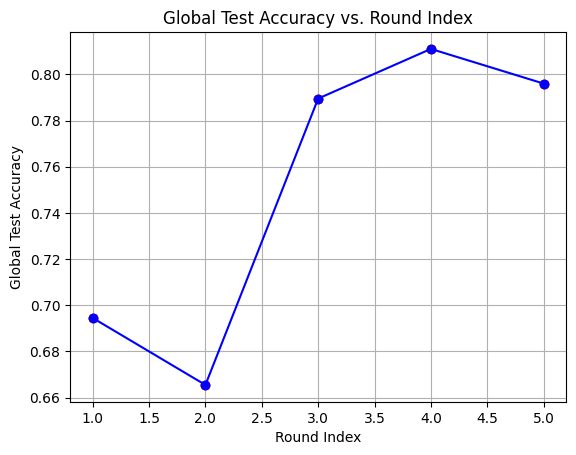

In [36]:
import matplotlib.pyplot as plt

# Example points (replace with your own x and y values)
x = accuracy_plot_x
y = accuracy_plot_y

# Scatter plot of points
plt.scatter(x, y, color='red', zorder=2)

# Plot line with markers
plt.plot(x, y, marker='o', linestyle='-', color='blue')

# Highlight the points explicitly if you like
plt.scatter(x, y, color='red')

plt.xlabel("Round Index")
plt.ylabel("Global Test Accuracy")
plt.title("Global Test Accuracy vs. Round Index")
plt.grid(True)
plt.show()
